# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 6 - Analysis including Airbnb

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#!pip install h3
import h3
import matplotlib.patches as mpatches
import seaborn as sns
#!pip install scipy
from scipy.stats import skew
import statsmodels.api as sm

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results
df_dir = os.path.join(current_path, "dataframes")

In [3]:
# Load any dataframe from that folder
admin_city = gpd.read_file(os.path.join(df_dir, "admin_city_vienna.geojson"))
urban_green_spaces =gpd.read_file(os.path.join(df_dir, "urban_green_spaces.geojson"))
urban_blue_spaces = gpd.read_file(os.path.join(df_dir, "urban_blue_spaces.geojson"))
ugbs_socioecon_census = gpd.read_file(os.path.join(df_dir, "ugbs_socioecon_census.geojson"))
socioecon_districts = gpd.read_file(os.path.join(df_dir, "socioecon_districts.geojson"))
merged_census = gpd.read_file(os.path.join(df_dir, "merged_census.geojson"))
housingprices_district = gpd.read_file(os.path.join(df_dir, "housingprices_district.geojson"))
social_housing = pd.read_csv(os.path.join(df_dir, "social_housing.csv"))
social_housing_gdf = gpd.read_file(os.path.join(df_dir, "social_housing.geojson"))
aptfeatures_social_census = pd.read_csv(os.path.join(df_dir, "aptfeatures_social_census.csv"))
apt_features_final_census = pd.read_csv(os.path.join(df_dir, "apt_features_final_census.csv"))
airbnb_entireunits_gdf = gpd.read_file(os.path.join(df_dir, "airbnb_entireunits.geojson"))
res_centroids = gpd.read_file(os.path.join(df_dir, "residential_centroids_300m.geojson"))
social_centroids = gpd.read_file(os.path.join(df_dir, "social_centroids_300m.geojson"))
airbnb_centroids = gpd.read_file(os.path.join(df_dir, "airbnb_centroids_300m.geojson"))
#annual_airbnb_gdf = gpd.read_file(os.path.join(df_dir, "annual_airbnb_entire.geojson"))

Skipping field ways: unsupported OGR type: 1
Skipping field amenities: unsupported OGR type: 5
Skipping field ways: unsupported OGR type: 1


### Correlation check
#### for airbnb last year's prices and apartment prices per district
* apartment prices per district and airbnb prices per district
* if they are correlated highly, I can use airbnb prices instead of the real apartment rental prices - which might provide better estimation than using average income per census district as a proxy.
* I will use the following 2 dataframes
    * housingprices_district
    * airbnb_centroids

* Steps:
    * put district numbers to airbnbs based on their address or geometry
    * check the correlation

In [4]:
airbnb_centroids.columns.to_list()

['id',
 'price_20250305',
 'review_20250305',
 'price_20241212',
 'review_20241212',
 'price_20240911',
 'review_20240911',
 'price_20240615',
 'review_20240615',
 'avg_price',
 'avg_review',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'property_type_grouped',
 'property_type',
 'bathrooms',
 'bedrooms',
 'distance_to_ugs',
 'distance_to_ubs',
 'distance_to_ugbs',
 'within_300m',
 'geometry']

In [5]:
print(airbnb_centroids.crs)
print(housingprices_district.crs)

EPSG:31256
EPSG:4326


In [6]:
# ensuring they are both in same CRS
housingprices_district = housingprices_district.to_crs(airbnb_centroids.crs)

# Spatial join to determine Airbnbs district codes.
airbnb_with_district = gpd.sjoin(airbnb_centroids, housingprices_district[['BEZ', 'geometry']], how='left', predicate='within')

print(airbnb_with_district.columns)

Index(['id', 'price_20250305', 'review_20250305', 'price_20241212',
       'review_20241212', 'price_20240911', 'review_20240911',
       'price_20240615', 'review_20240615', 'avg_price', 'avg_review',
       'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type_grouped', 'property_type', 'bathrooms', 'bedrooms',
       'distance_to_ugs', 'distance_to_ubs', 'distance_to_ugbs', 'within_300m',
       'geometry', 'index_right', 'BEZ'],
      dtype='object')


In [7]:
# aggregate airbnb prices per district
airbnb_prices_district = (
    airbnb_with_district
    .groupby('BEZ')['avg_price']
    .mean()
    .reset_index()
    .rename(columns={'avg_price': 'annual_airbnbprice_district'})
)

In [8]:
merged_prices = pd.merge(housingprices_district, airbnb_prices_district, on='BEZ')

# If apartment prices are under a different name:
merged_prices = merged_prices.rename(columns={'avg_price_years': 'avg_apartment_price'})

# Correlation of districts (excluding Innere Stadt, i.e. BEZ==01)
merged_prices_filtered = merged_prices[merged_prices['BEZ'] != '01']
# print(merged_prices.columns.to_list())

# Compute correlation
corr1 = merged_prices[['annual_airbnbprice_district', 'avg_apartment_price']].corr().iloc[0, 1]
corr2_excl01 = merged_prices_filtered[['annual_airbnbprice_district', 'avg_apartment_price']].corr().iloc[0, 1]

print("Correlation between Airbnb prices and apartment rental prices:", round(corr1, 3))
print("Correlation between Airbnb prices and apartment rental prices (excluding Innere Stadt):", round(corr2_excl01, 3))

Correlation between Airbnb prices and apartment rental prices: 0.888
Correlation between Airbnb prices and apartment rental prices (excluding Innere Stadt): 0.675


In [9]:
# Step 1: Select only relevant columns
plot_df = merged_prices[['annual_airbnbprice_district', 'avg_apartment_price']].copy()
plot_df_filtered = merged_prices_filtered[['annual_airbnbprice_district', 'avg_apartment_price']].copy()

# Step 2: Convert all to numeric (safety check)
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
plot_df_filtered = plot_df_filtered.apply(pd.to_numeric, errors='coerce')

# Step 3: Drop rows with NaNs
plot_df = plot_df.dropna()
plot_df_filtered = plot_df_filtered.dropna()


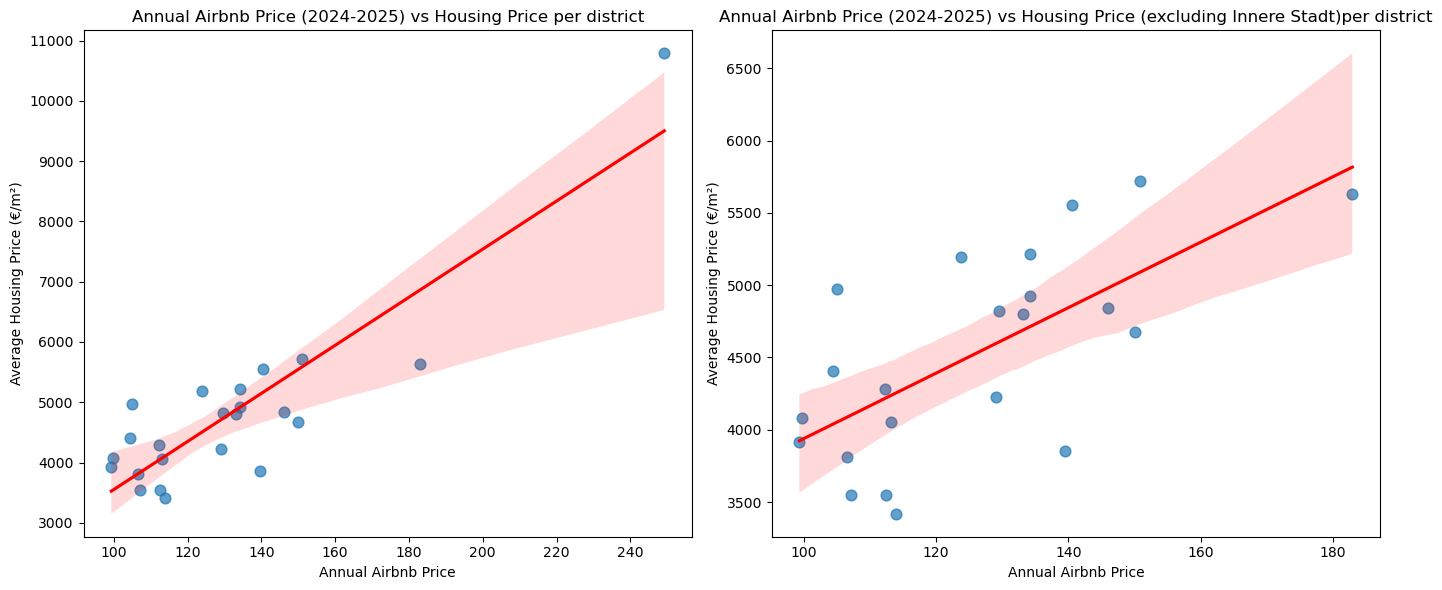

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price
sns.regplot(
    data=plot_df,
    x='annual_airbnbprice_district',
    y='avg_apartment_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Annual Airbnb Price (2024-2025) vs Housing Price per district')
axes[0].set_xlabel('Annual Airbnb Price')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# district_SSI vs avg_price
sns.regplot(
    data=plot_df_filtered,
    x='annual_airbnbprice_district',
    y='avg_apartment_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('Annual Airbnb Price (2024-2025) vs Housing Price (excluding Innere Stadt)per district')
axes[1].set_xlabel('Annual Airbnb Price')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/annualairbnb_aptprice_corr.png", dpi=300, bbox_inches='tight')
plt.show()

### Descriptive Stats for Final Airbnb Sample

In [11]:
airbnb_samplestats = airbnb_centroids.groupby('property_type_grouped').agg(
    bathrooms_min=('bathrooms', 'min'),
    bathrooms_mean=('bathrooms', 'mean'),
    bathrooms_max=('bathrooms', 'max'),
    bathrooms_median=('bathrooms', 'median'),
    
    bedrooms_min=('bedrooms', 'min'),
    bedrooms_mean=('bedrooms', 'mean'),
    bedrooms_max=('bedrooms', 'max'),
    bedrooms_median=('bedrooms', 'median'),
    
    price_min=('avg_price', 'min'),
    price_mean=('avg_price', 'mean'),
    price_max=('avg_price', 'max'),
    price_median=('avg_price', 'median'),

    review_min=('avg_review', 'min'),
    review_mean=('avg_review', 'mean'),
    review_max=('avg_review', 'max'),
    review_median=('avg_review', 'median'),

    distance_union_min=('distance_to_ugbs', 'min'),
    distance_union_mean=('distance_to_ugbs', 'mean'),
    distance_union_max=('distance_to_ugbs', 'max'),
    distance_union_median=('distance_to_ugbs', 'median'),
    
    count=('avg_price', 'count')
).round(2).reset_index()

print(len(airbnb_samplestats))
airbnb_samplestats

3


,property_type_grouped,bathrooms_min,bathrooms_mean,bathrooms_max,bathrooms_median,bedrooms_min,bedrooms_mean,bedrooms_max,bedrooms_median,price_min,...,price_median,review_min,review_mean,review_max,review_median,distance_union_min,distance_union_mean,distance_union_max,distance_union_median,count
0,Entire Apartment,0.0,1.18,12.0,1.0,0.0,1.33,12.0,1.0,19.50,...,100.00,1.00,4.74,5.00,4.82,0.0,112.22,531.27,102.31,6762
1,Entire House,0.5,1.54,6.5,1.5,0.0,2.26,11.0,2.0,37.00,...,132.25,2.84,4.74,5.00,4.84,0.0,146.32,531.30,113.98,139
2,Other,1.0,1.17,1.5,1.0,0.0,1.12,2.0,1.0,62.75,...,116.25,4.00,4.57,4.86,4.64,45.0,115.81,342.89,77.81,6


### OLS airbnb prices - ugbs

In [12]:
# check for any NaNs
print(airbnb_centroids['avg_price'].isna().any())
print(airbnb_centroids['avg_price'].isna().sum())
print(airbnb_centroids['avg_review'].isna().any())
print(airbnb_centroids['avg_review'].isna().sum())
print(airbnb_centroids['distance_to_ugbs'].isna().any())
print(airbnb_centroids['distance_to_ugbs'].isna().sum())
print(airbnb_centroids['bedrooms'].isna().any())
print(airbnb_centroids['bedrooms'].isna().sum())


True
1532
True
921
False
0
True
243


In [13]:
airbnb_centroids[airbnb_centroids['avg_review'].isna() & airbnb_centroids['avg_price'].isna()]

,id,price_20250305,review_20250305,price_20241212,review_20241212,price_20240911,review_20240911,price_20240615,review_20240615,avg_price,...,longitude,property_type_grouped,property_type,bathrooms,bedrooms,distance_to_ugs,distance_to_ubs,distance_to_ugbs,within_300m,geometry
26,23324521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.288580,Entire Apartment,Entire rental unit,NaN,1.0,134.743981,349.780380,134.743981,True,POINT (-3241.692 333773.196)
40,20780943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.272070,Entire House,Entire home,NaN,1.0,413.947415,362.803065,362.803065,False,POINT (-4470.283 333875.274)
102,46248902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.325030,Entire Apartment,Entire rental unit,NaN,1.0,10.344723,346.741802,10.344723,True,POINT (-528.601 337086.852)
117,24550232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.327310,Entire Apartment,Entire rental unit,NaN,1.0,96.003921,557.738146,96.003921,True,POINT (-358.99 337354.808)
126,2548906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.330244,Entire Apartment,Entire rental unit,NaN,1.0,81.972572,731.305002,81.972572,True,POINT (-140.791 337129.303)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8378,23181110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.462440,Entire House,Entire home,NaN,2.0,51.160131,936.348718,51.160131,True,POINT (9675.069 347115.404)
8396,41532354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.404800,Entire Apartment,Entire rental unit,NaN,NaN,124.608418,633.772491,124.608418,True,POINT (5394.498 348226.379)
8405,15474601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.421630,Entire Apartment,Entire condo,NaN,NaN,220.212026,658.576227,220.212026,True,POINT (6645.132 347052.291)
8419,54399795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.460080,Entire Apartment,Entire condo,NaN,2.0,231.277011,463.129597,231.277011,True,POINT (9497.188 348761.932)


In [14]:
initial_len = len(airbnb_centroids)
airbnb_centroids = airbnb_centroids[~(
    airbnb_centroids['avg_review'].isna() & airbnb_centroids['avg_price'].isna()
)]

In [15]:
airbnb_centroids = airbnb_centroids[~(
    airbnb_centroids['avg_price'].isna())]
final_len = len(airbnb_centroids)

In [16]:
print(f"Rows dropped: {initial_len - final_len}")

Rows dropped: 1532


In [17]:
# List of controls to impute
control_vars = ['avg_review', 'bedrooms', 'bathrooms']

# Impute each control using the mean within its property_type_grouped
for col in control_vars:
    group_mean = airbnb_centroids.groupby('property_type_grouped')[col].transform('mean')
    airbnb_centroids[col] = airbnb_centroids[col].fillna(group_mean)


In [18]:
# 1. Drop rows where key variables are missing
df = airbnb_centroids.dropna(subset=['avg_price', 'distance_to_ugbs']).copy()

# 2. Create distance squared term for non-linearity
df['distance_to_ugbs_sq'] = df['distance_to_ugbs'] ** 2

# 3. Define X and y
X = df[['distance_to_ugbs', 'distance_to_ugbs_sq'] + control_vars]
X = sm.add_constant(X)
y = df['avg_price']

# 4. Fit OLS model
model_airbnb = sm.OLS(y, X).fit()

# 5. Output summary
print(model_airbnb.summary())

# Save the model without dummies and not-robust errors
with open("output/model_airbnb.txt", "w") as f:
    f.write(model_airbnb.summary().as_text())

# Save to a .tex file
latex_table_base = model_airbnb.summary().as_latex()
with open("output_latex/regression_base.tex", "w") as f:
    f.write(latex_table_base)

                            OLS Regression Results                            
Dep. Variable:              avg_price   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     112.4
Date:                Sun, 18 May 2025   Prob (F-statistic):          1.40e-114
Time:                        20:05:42   Log-Likelihood:                -45194.
No. Observations:                6907   AIC:                         9.040e+04
Df Residuals:                    6901   BIC:                         9.044e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  26.9997    

In [19]:
# Step 5: Create dummies from grouped property types (drop one to avoid multicollinearity)
property_dummies = pd.get_dummies(df['property_type_grouped'], prefix='ptype', drop_first=True)

# Step 6–7: Build and clean full matrix
X = pd.concat([
    df[['distance_to_ugbs', 'distance_to_ugbs_sq'] + control_vars],
    property_dummies
], axis=1)

# Combine with y temporarily
X['avg_price'] = df['avg_price']

# Drop rows with any NaNs in X or y
X = X.dropna()

# Split back to X and y
y = X['avg_price']
X = X.drop(columns=['avg_price'])

# Final safeguard: force all to numeric float64
X = X.astype(np.float64)
y = y.astype(np.float64)

# Step 8: Add intercept and fit model
X = sm.add_constant(X)
model_grouped = sm.OLS(y, X).fit()
model_gr_robust = sm.OLS(y, X).fit(cov_type='HC1')

# Step 9: Print results
print(model_grouped.summary())
print(model_gr_robust.summary())

# Save both models with property type dummies, and one with robust standard errors
# Model 1
with open("output/model_grouped.txt", "w") as f:
    f.write(model_grouped.summary().as_text())

# Save to a .tex file
latex_table_nonrobust = model_grouped.summary().as_latex()
with open("output_latex/regression_dummy_nonrobust.tex", "w") as f:
    f.write(latex_table_nonrobust)

# Model 2
with open("output/model_grouped_robust.txt", "w") as f:
    f.write(model_gr_robust.summary().as_text())

latex_table_robust = model_gr_robust.summary().as_latex()
with open("output_latex/regression_dummy_robust.tex", "w") as f:
    f.write(latex_table_robust)

                            OLS Regression Results                            
Dep. Variable:              avg_price   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     81.73
Date:                Sun, 18 May 2025   Prob (F-statistic):          1.54e-114
Time:                        20:05:42   Log-Likelihood:                -45189.
No. Observations:                6907   AIC:                         9.039e+04
Df Residuals:                    6899   BIC:                         9.045e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  28.0195    

##### Only with UGS (not blue space)

In [20]:
# Create distance squared term for non-linearity
df['distance_to_ugs_sq'] = df['distance_to_ugs'] ** 2

# Build and clean full matrix
X = pd.concat([
    df[['distance_to_ugs', 'distance_to_ugs_sq'] + control_vars],
    property_dummies
], axis=1)

# Combine with y temporarily
X['avg_price'] = df['avg_price']

# Drop rows with any NaNs in X or y
X = X.dropna()

# Split back to X and y
y = X['avg_price']
X = X.drop(columns=['avg_price'])

# Final safeguard: force all to numeric float64
X = X.astype(np.float64)
y = y.astype(np.float64)

# Step 8: Add intercept and fit model
X = sm.add_constant(X)
model_ugs_grouped = sm.OLS(y, X).fit()
model_gr_ugs_robust = sm.OLS(y, X).fit(cov_type='HC1')

# Step 9: Print results
print(model_ugs_grouped.summary())
print(model_gr_ugs_robust.summary())

                            OLS Regression Results                            
Dep. Variable:              avg_price   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     81.71
Date:                Sun, 18 May 2025   Prob (F-statistic):          1.62e-114
Time:                        20:05:43   Log-Likelihood:                -45189.
No. Observations:                6907   AIC:                         9.039e+04
Df Residuals:                    6899   BIC:                         9.045e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 22.5339     28

### Average income - ugbs

#### Correlation check
##### for average income per census district and apartment prices per district
* we know from notebook 04.Analysis, average income per district is 0.8 correlated with apartment prices
* Unlike airbnb's, since census districts are way larger and a complex of many buildings, I can only look OLS through distance bins
    * (in addition to what I did in notebook04 with green-blue ratios per census district)
 
##### Distance bins method, step-by-step
* 3 distance bins: within census district, neighbouring, further away than neighbouring
* check green area ratios per census district
* flag census T/F. T if more than mean/median green area exist within that census district. 
* move along within, neighbour, further
* OLS with those distance bins

In [21]:
print(merged_census.columns)

Index(['index', 'ZBEZ', 'green_area_sum', 'university_share', 'avg_income',
       'unemprate', 'benefit_share', 'SSI', 'quintile', 'blue_area_sum',
       'census_area_m2', 'green_ratio', 'blue_ratio', 'BEZ',
       'total_apartments', 'no_central_heating', 'central_heating',
       'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other',
       'social_housing_units', 'social_housing_ratio', 'centralheating_rate',
       'private_ownership_rate', 'geometry'],
      dtype='object')


In [22]:
print("Min Green Ratio:", merged_census["green_ratio"].min())
print("Max Green Ratio:", merged_census["green_ratio"].max())
print("Mean Green Ratio:", merged_census["green_ratio"].mean())
print("Median Green Ratio:", merged_census["green_ratio"].median())

print("Min Blue Ratio:", merged_census["blue_ratio"].min())
print("Max Blue Ratio:", merged_census["blue_ratio"].max())
print("Mean Blue Ratio:", merged_census["blue_ratio"].mean())
print("Median Blue Ratio:", merged_census["blue_ratio"].median())

Min Green Ratio: 0.0
Max Green Ratio: 15.845
Mean Green Ratio: 0.7186056910569105
Median Green Ratio: 0.11449999999999999
Min Blue Ratio: 0.996
Max Blue Ratio: 1.067
Mean Blue Ratio: 1.003260162601626
Median Blue Ratio: 1.0


### OLS: airbnb price ~ avg_income
* didnt do
* not sure whether it is necessary or not